# Prediccion de Desercion Escolar en Ecuador
### Aprendizaje Supervisado sobre datos AMIE - Ministerio de Educacion
**Materia:** Conceptos y Aplicaciones de Machine Learning  
**Fuente:** [educacion.gob.ec/base-de-datos](https://educacion.gob.ec/base-de-datos/)  
**Periodo:** 2015-2016 a 2024-2025 | **Enfoque:** Random Forest - Clasificacion multiclase  
**Modelo de datos:** `amie_model.py` (Enums + Dataclass OOP)


---
## Fuente de Datos

Los datos utilizados en este notebook provienen del sitio oficial del **Ministerio de Educación del Ecuador**:

> **Portal:** [educacion.gob.ec/base-de-datos](https://educacion.gob.ec/base-de-datos/)  
> **Sección:** AMIE — Registros Administrativos del Sistema Educativo  
> **URL de descarga original:** `https://educacion.gob.ec/wp-content/uploads/downloads/`

### Disponibilidad local

Para garantizar la reproducibilidad del análisis **sin dependencia de conectividad a internet**, todos los archivos CSV han sido descargados y almacenados directamente en el directorio `data/` de este repositorio.  
El índice de archivos disponibles se encuentra en `data/index.json`.

| Periodo | Archivo Inicio | Archivo Fin |
|---------|---------------|-------------|
| 2015-2016 | `data/2015-2016_Inicio.csv` | `data/2015-2016_Fin.csv` |
| 2016-2017 | `data/2016-2017_Inicio.csv` | `data/2016-2017_Fin.csv` |
| 2017-2018 | `data/2017-2018_Inicio.csv` | `data/2017-2018_Fin.csv` |
| 2018-2019 | `data/2018-2019_Inicio.csv` | `data/2018-2019_Fin.csv` |
| 2019-2020 | `data/2019-2020_Inicio.csv` | `data/2019-2020_Fin.csv` |
| 2020-2021 | `data/2020-2021_Inicio.csv` | `data/2020-2021_Fin.csv` |
| 2021-2022 | `data/2021-2022_Inicio.csv` | `data/2021-2022_Fin.csv` |
| 2022-2023 | `data/2022-2023_Inicio.csv` | `data/2022-2023_Fin.csv` |
| 2023-2024 | `data/2023-2024_Inicio.csv` | `data/2023-2024_Fin.csv` |
| 2024-2025 | `data/2024-2025_Inicio.csv` | `data/2024-2025_Fin.csv` |


---
## 1. Definicion del Problema

### Contexto
La desercion escolar es uno de los principales desafios del sistema educativo ecuatoriano. Cada anio miles de estudiantes abandonan sus estudios antes de completar el anio lectivo, afectando indicadores de desarrollo humano y perpetuando ciclos de pobreza.

### Pregunta de Investigacion
> **Es posible predecir el nivel de desercion escolar de una institucion educativa basandose en sus caracteristicas institucionales, geograficas y de recursos?**

### Variable Objetivo
```
tasa_desercion = (Total_Inicio - Total_Fin) / Total_Inicio
```

Clasificada en tres niveles via `NivelDesercion` (Enum):
- **BAJO** (< 5%) : Retencion aceptable
- **MEDIO** (5-15%) : Alerta moderada
- **ALTO** (> 15%) : Alerta critica

### Reduccion de dimensionalidad
De **74 columnas originales** se conservan **17 features utiles**:
- Se eliminan 44 columnas de conteo por grado (multicolinealidad con Total Estudiantes)
- Se eliminan identificadores redundantes (Cod_Provincia, Canton, Parroquia, Nombre)
- Se elimina `Escolarizacion` (un unico valor en todo el dataset, cero varianza)
- Los strings categoricos se reemplazan por Enums con valores enteros ordinales


---
## 2. Dependencias y Configuracion


In [12]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings('ignore')

import os, sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import PCA


sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)


---
## 3. Modelo de Dominio — Enums y Dataclass

Se definen los **12 Enums** y la clase `InstitucionEducativa` directamente en el notebook. Cada Enum reemplaza una columna de texto categorico del CSV con un valor entero ordinal, eliminando la necesidad de `LabelEncoder`. La clase `InstitucionEducativa` encapsula la logica de construccion, validacion y exportacion de features para sklearn.


In [13]:
"""
amie_model.py
=============
Modelo de dominio para el dataset AMIE del Ministerio de Educación del Ecuador.

Contiene:
  - 12 clases Enum que reemplazan strings categóricos
  - Funciones normalizadoras para valores compuestos (Modalidad, Jornada, Nivel)
  - Dataclass InstitucionEducativa con tipado fuerte
  - Método from_row()    → construye una instancia desde una fila de DataFrame
  - Property features_ml → retorna dict numérico listo para sklearn
  - Método validar()     → detecta inconsistencias en los datos

Uso:
    instituciones = build_dataset(df_inicio, df_fin, anio)
    X = [inst.features_ml for inst in instituciones]
"""

from __future__ import annotations

from dataclasses import dataclass, field
from enum import Enum
from typing import Optional
import pandas as pd
import numpy as np


# ══════════════════════════════════════════════════════════════════════════════
# 1. ENUMERADOS
# ══════════════════════════════════════════════════════════════════════════════

class Sostenimiento(Enum):
    """Tipo de financiamiento de la institución educativa."""
    FISCAL          = 1
    PARTICULAR      = 2
    FISCOMISIONAL   = 3
    MUNICIPAL       = 4
    DESCONOCIDO     = 0

    @classmethod
    def from_str(cls, valor: str) -> "Sostenimiento":
        mapa = {
            "fiscal":        cls.FISCAL,
            "particular":    cls.PARTICULAR,
            "fiscomisional": cls.FISCOMISIONAL,
            "municipal":     cls.MUNICIPAL,
        }
        return mapa.get(str(valor).strip().lower(), cls.DESCONOCIDO)


class Area(Enum):
    """Ubicación geográfica de la institución."""
    URBANA      = 1
    RURAL       = 2
    DESCONOCIDO = 0

    @classmethod
    def from_str(cls, valor: str) -> "Area":
        mapa = {
            "urbana": cls.URBANA,
            "rural":  cls.RURAL,
        }
        return mapa.get(str(valor).strip().lower(), cls.DESCONOCIDO)


class Regimen(Enum):
    """Régimen escolar según zona geográfica del Ecuador."""
    COSTA    = 1
    SIERRA   = 2
    AMAZONIA = 3   # puede aparecer en períodos anteriores
    INSULAR  = 4
    DESCONOCIDO = 0

    @classmethod
    def from_str(cls, valor: str) -> "Regimen":
        mapa = {
            "costa":    cls.COSTA,
            "sierra":   cls.SIERRA,
            "amazonia": cls.AMAZONIA,
            "amazónica":cls.AMAZONIA,
            "insular":  cls.INSULAR,
        }
        return mapa.get(str(valor).strip().lower(), cls.DESCONOCIDO)


class Jurisdiccion(Enum):
    """Jurisdicción educativa (lengua de instrucción)."""
    INTERCULTURAL          = 1
    INTERCULTURAL_BILINGUE = 2
    DESCONOCIDO            = 0

    @classmethod
    def from_str(cls, valor: str) -> "Jurisdiccion":
        v = str(valor).strip().lower()
        if "bilingü" in v or "bilingue" in v:
            return cls.INTERCULTURAL_BILINGUE
        if "intercultural" in v:
            return cls.INTERCULTURAL
        return cls.DESCONOCIDO


class ModalidadPrimaria(Enum):
    """
    Modalidad de enseñanza principal.
    Cuando el campo contiene combinaciones (ej. 'Presencial y A Distancia'),
    se toma la primera modalidad listada como primaria.
    """
    PRESENCIAL     = 1
    SEMIPRESENCIAL = 2
    DISTANCIA      = 3
    VIRTUAL        = 4
    RADIOFONICA    = 5
    EN_CASA        = 6
    OTRO           = 0

    @classmethod
    def from_str(cls, valor: str) -> "ModalidadPrimaria":
        v = str(valor).strip().lower()
        # Orden de prioridad: tomar la primera modalidad mencionada
        if v.startswith("presencial"):
            return cls.PRESENCIAL
        if v.startswith("semipresencial"):
            return cls.SEMIPRESENCIAL
        if "radiofónica" in v or "radiofonica" in v:
            return cls.RADIOFONICA
        if "en casa" in v or "educación en casa" in v:
            return cls.EN_CASA
        if "a distancia" in v:
            return cls.DISTANCIA
        if "virtual" in v or "en línea" in v or "en linea" in v:
            return cls.VIRTUAL
        if "red virtual" in v:
            return cls.VIRTUAL
        return cls.OTRO


class JornadaPrimaria(Enum):
    """
    Jornada escolar principal.
    Cuando el campo contiene combinaciones (ej. 'Matutina y Nocturna'),
    se toma la primera jornada listada como primaria.
    """
    MATUTINA   = 1
    VESPERTINA = 2
    NOCTURNA   = 3
    COMPLETA   = 4   # jornada extendida / todo el día
    DESCONOCIDO = 0

    @classmethod
    def from_str(cls, valor: str) -> "JornadaPrimaria":
        v = str(valor).strip().lower()
        if v.startswith("matutina"):
            return cls.MATUTINA
        if v.startswith("vespertina"):
            return cls.VESPERTINA
        if v.startswith("nocturna"):
            return cls.NOCTURNA
        if "completa" in v or "doble" in v:
            return cls.COMPLETA
        return cls.DESCONOCIDO


class NivelEducacion(Enum):
    """
    Nivel educativo principal de la institución.
    Valores combinados se agrupan en la categoría más alta presente.
    """
    INICIAL       = 1
    BASICA        = 2
    BACHILLERATO  = 3
    MULTI_NIVEL   = 4   # combina dos o más niveles
    OTRO          = 0   # Alfabetización, Artesanal, etc.

    @classmethod
    def from_str(cls, valor: str) -> "NivelEducacion":
        v = str(valor).strip().lower()
        tiene_bach  = "bachillerato" in v or "bach" in v
        tiene_egb   = "básica" in v or "basica" in v or "egb" in v
        tiene_ini   = "inicial" in v
        tiene_otro  = "alfabetización" in v or "alfabetizacion" in v \
                      or "artesanal" in v or "artesanal" in v

        combinados = sum([tiene_bach, tiene_egb, tiene_ini, tiene_otro])

        if combinados > 1:
            return cls.MULTI_NIVEL
        if tiene_bach:
            return cls.BACHILLERATO
        if tiene_egb:
            return cls.BASICA
        if tiene_ini:
            return cls.INICIAL
        return cls.OTRO


class TipoEducacion(Enum):
    """Tipo de oferta educativa."""
    ORDINARIA              = 1
    ESPECIAL               = 2
    ESCOLARIDAD_INCONCLUSA = 3
    DESCONOCIDO            = 0

    @classmethod
    def from_str(cls, valor: str) -> "TipoEducacion":
        v = str(valor).strip().lower()
        if "ordinaria" in v:
            return cls.ORDINARIA
        if "especial" in v:
            return cls.ESPECIAL
        if "inconclusa" in v:
            return cls.ESCOLARIDAD_INCONCLUSA
        return cls.DESCONOCIDO


class TenenciaEdificio(Enum):
    """
    Situación legal del inmueble donde funciona la institución.
    Agrupado en tres categorías para reducir dispersión.
    """
    PROPIO      = 1   # "Propio"
    NO_PROPIO   = 2   # Arriendo, Prestado, Comodato, Cesión de derechos
    DESCONOCIDO = 0   # No conoce, Invasión, o nulo

    @classmethod
    def from_str(cls, valor: str) -> "TenenciaEdificio":
        v = str(valor).strip().lower()
        if v == "propio":
            return cls.PROPIO
        if v in ("arriendo", "prestado", "comodato",
                 "cesión de derechos", "cesion de derechos"):
            return cls.NO_PROPIO
        return cls.DESCONOCIDO


class AccesoEdificio(Enum):
    """Tipo de vía de acceso a la institución."""
    TERRESTRE   = 1
    FLUVIAL     = 2
    AEREA       = 3
    DESCONOCIDO = 0

    @classmethod
    def from_str(cls, valor: str) -> "AccesoEdificio":
        mapa = {
            "terrestre": cls.TERRESTRE,
            "fluvial":   cls.FLUVIAL,
            "aérea":     cls.AEREA,
            "aerea":     cls.AEREA,
        }
        return mapa.get(str(valor).strip().lower(), cls.DESCONOCIDO)


class ZonaAdministrativa(Enum):
    """
    Zona de planificación administrativa del Ecuador (SENPLADES).
    El valor entero del Enum se usa directamente como feature numérica.
    Zona en Estudio = 0 (sin zona asignada aún).
    """
    ZONA_EN_ESTUDIO = 0
    ZONA_1 = 1   # Esmeraldas, Carchi, Imbabura, Sucumbíos
    ZONA_2 = 2   # Pichincha (excl. Quito), Napo, Orellana
    ZONA_3 = 3   # Cotopaxi, Tungurahua, Chimborazo, Pastaza
    ZONA_4 = 4   # Manabí, Santo Domingo de los Tsáchilas
    ZONA_5 = 5   # Santa Elena, Guayas (excl. Guayaquil), Bolívar, Los Ríos, Galápagos
    ZONA_6 = 6   # Azuay, Cañar, Morona Santiago
    ZONA_7 = 7   # El Oro, Loja, Zamora Chinchipe
    ZONA_8 = 8   # Guayaquil, Samborondón, Durán
    ZONA_9 = 9   # Quito (Distrito Metropolitano)

    @classmethod
    def from_str(cls, valor: str) -> "ZonaAdministrativa":
        v = str(valor).strip().lower().replace(" ", "_")
        mapa = {
            "zona_1": cls.ZONA_1, "zona_2": cls.ZONA_2,
            "zona_3": cls.ZONA_3, "zona_4": cls.ZONA_4,
            "zona_5": cls.ZONA_5, "zona_6": cls.ZONA_6,
            "zona_7": cls.ZONA_7, "zona_8": cls.ZONA_8,
            "zona_9": cls.ZONA_9,
            "zona_en_estudio": cls.ZONA_EN_ESTUDIO,
        }
        return mapa.get(v, cls.ZONA_EN_ESTUDIO)


class NivelDesercion(Enum):
    """Variable objetivo del modelo de clasificación."""
    BAJO  = 0   # tasa < 5%
    MEDIO = 1   # 5% <= tasa <= 15%
    ALTO  = 2   # tasa > 15%

    @classmethod
    def from_tasa(cls, tasa: float) -> "NivelDesercion":
        if tasa < 0.05:
            return cls.BAJO
        if tasa <= 0.15:
            return cls.MEDIO
        return cls.ALTO

    def label(self) -> str:
        return self.name.capitalize()


# ══════════════════════════════════════════════════════════════════════════════
# 2. DATACLASS — MODELO DE DOMINIO
# ══════════════════════════════════════════════════════════════════════════════

@dataclass
class InstitucionEducativa:
    """
    Representa una institución educativa en un año lectivo específico.
    Combina datos del archivo Inicio y Fin del AMIE.

    Atributos de identificación (no usados en ML):
        amie, anio_lectivo, provincia

    Atributos categóricos (Enum → valor entero en features_ml):
        zona, sostenimiento, area, regimen, jurisdiccion,
        modalidad, jornada, nivel_educacion, tipo_educacion,
        acceso_edificio, tenencia_edificio

    Atributos numéricos:
        total_docentes, total_administrativos,
        est_inicio, est_fin,
        ratio_doc_est, ratio_genero_est

    Atributos derivados (target):
        tasa_desercion, nivel_desercion
    """

    # ── Identificación ────────────────────────────────────────────────────────
    amie:            str
    anio_lectivo:    str
    provincia:       str

    # ── Categóricos tipados ───────────────────────────────────────────────────
    zona:             ZonaAdministrativa
    sostenimiento:    Sostenimiento
    area:             Area
    regimen:          Regimen
    jurisdiccion:     Jurisdiccion
    modalidad:        ModalidadPrimaria
    jornada:          JornadaPrimaria
    nivel_educacion:  NivelEducacion
    tipo_educacion:   TipoEducacion
    acceso_edificio:  AccesoEdificio
    tenencia_edificio: TenenciaEdificio

    # ── Numéricos ─────────────────────────────────────────────────────────────
    total_docentes:       float
    total_administrativos: float
    est_inicio:           float
    est_fin:              float
    ratio_doc_est:        float   # docentes por estudiante
    ratio_genero_est:     float   # femenino / total (0–1)

    # ── Target ───────────────────────────────────────────────────────────────
    tasa_desercion:  float
    nivel_desercion: NivelDesercion

    # ── Propiedades ───────────────────────────────────────────────────────────

    @property
    def features_ml(self) -> dict:
        """
        Retorna un diccionario con todas las features en formato numérico,
        listo para construir un DataFrame de entrada a sklearn.
        Los Enums se representan por su valor entero (.value).
        """
        return {
            # Categóricas (valor entero del Enum)
            "zona":              self.zona.value,
            "sostenimiento":     self.sostenimiento.value,
            "area":              self.area.value,
            "regimen":           self.regimen.value,
            "jurisdiccion":      self.jurisdiccion.value,
            "modalidad":         self.modalidad.value,
            "jornada":           self.jornada.value,
            "nivel_educacion":   self.nivel_educacion.value,
            "tipo_educacion":    self.tipo_educacion.value,
            "acceso_edificio":   self.acceso_edificio.value,
            "tenencia_edificio": self.tenencia_edificio.value,
            # Numéricas
            "total_docentes":        self.total_docentes,
            "total_administrativos": self.total_administrativos,
            "est_inicio":            self.est_inicio,
            "ratio_doc_est":         self.ratio_doc_est,
            "ratio_genero_est":      self.ratio_genero_est,
        }

    @property
    def target_ml(self) -> int:
        """Valor entero del nivel de deserción (para sklearn)."""
        return self.nivel_desercion.value

    @property
    def target_label(self) -> str:
        """Etiqueta de texto del nivel de deserción."""
        return self.nivel_desercion.label()

    # ── Validación ────────────────────────────────────────────────────────────

    def validar(self) -> list[str]:
        """
        Detecta inconsistencias en los datos.
        Retorna lista de mensajes de error (vacía si todo está OK).
        """
        errores = []

        if self.est_inicio <= 0:
            errores.append(f"[{self.amie}] est_inicio <= 0")

        if self.est_fin < 0:
            errores.append(f"[{self.amie}] est_fin negativo")

        if not (0.0 <= self.tasa_desercion <= 1.0):
            errores.append(f"[{self.amie}] tasa_desercion fuera de [0,1]: {self.tasa_desercion:.4f}")

        if self.total_docentes < 0:
            errores.append(f"[{self.amie}] total_docentes negativo")

        if self.zona == ZonaAdministrativa.ZONA_EN_ESTUDIO:
            errores.append(f"[{self.amie}] zona no asignada (Zona en Estudio)")

        if self.sostenimiento == Sostenimiento.DESCONOCIDO:
            errores.append(f"[{self.amie}] sostenimiento desconocido")

        return errores

    # ── Constructor desde fila de DataFrame ──────────────────────────────────

    @classmethod
    def from_row(
        cls,
        row_inicio: pd.Series,
        est_fin: float,
        anio_lectivo: str,
    ) -> Optional["InstitucionEducativa"]:
        """
        Construye una InstitucionEducativa desde una fila del DataFrame Inicio
        y el total de estudiantes al Fin de año.

        Retorna None si los datos mínimos no están disponibles.
        """
        def get(campo: str, default="") -> str:
            """Obtiene el valor de una columna de forma segura."""
            val = row_inicio.get(campo, default)
            return "" if pd.isna(val) else str(val).strip()

        def get_num(campo: str, default: float = 0.0) -> float:
            """Obtiene un valor numérico de forma segura."""
            val = row_inicio.get(campo, default)
            try:
                return float(val)
            except (ValueError, TypeError):
                return default

        # Datos mínimos necesarios
        amie      = get("amie")
        est_inicio = get_num("totalestudiantes")

        if not amie or est_inicio < 5:
            return None

        # Tasa de deserción
        est_fin_val    = max(0.0, float(est_fin)) if not pd.isna(est_fin) else 0.0
        tasa           = max(0.0, min(1.0, (est_inicio - est_fin_val) / est_inicio))
        nivel_des      = NivelDesercion.from_tasa(tasa)

        # Ratio docente / estudiante
        docentes = get_num("totaldocentes")
        ratio_doc = docentes / est_inicio if est_inicio > 0 else 0.0

        # Ratio de género estudiantes
        fem = get_num("estudiantesfemenino")
        total = est_inicio if est_inicio > 0 else 1.0
        ratio_gen = fem / total

        return cls(
            amie             = amie,
            anio_lectivo     = anio_lectivo,
            provincia        = get("provincia").upper(),

            zona             = ZonaAdministrativa.from_str(get("zona")),
            sostenimiento    = Sostenimiento.from_str(get("sostenimiento")),
            area             = Area.from_str(get("area")),
            regimen          = Regimen.from_str(get("regimenescolar")),
            jurisdiccion     = Jurisdiccion.from_str(get("jurisdiccion")),
            modalidad        = ModalidadPrimaria.from_str(get("modalidad")),
            jornada          = JornadaPrimaria.from_str(get("jornada")),
            nivel_educacion  = NivelEducacion.from_str(get("niveleducacion")),
            tipo_educacion   = TipoEducacion.from_str(get("tipoeducacion")),
            acceso_edificio  = AccesoEdificio.from_str(get("accesoedificio")),
            tenencia_edificio= TenenciaEdificio.from_str(get("tenenciainmuebleedificio")),

            total_docentes        = docentes,
            total_administrativos = get_num("totaladministrativos"),
            est_inicio            = est_inicio,
            est_fin               = est_fin_val,
            ratio_doc_est         = ratio_doc,
            ratio_genero_est      = ratio_gen,

            tasa_desercion   = tasa,
            nivel_desercion  = nivel_des,
        )

    def __repr__(self) -> str:
        return (
            f"InstitucionEducativa("
            f"amie={self.amie!r}, anio={self.anio_lectivo!r}, "
            f"provincia={self.provincia!r}, "
            f"area={self.area.name}, sostenimiento={self.sostenimiento.name}, "
            f"tasa={self.tasa_desercion:.2%}, nivel={self.nivel_desercion.name})"
        )


# ══════════════════════════════════════════════════════════════════════════════
# 3. FUNCIÓN DE CONSTRUCCIÓN DEL DATASET
# ══════════════════════════════════════════════════════════════════════════════

def build_dataset(
    df_inicio: pd.DataFrame,
    df_fin: pd.DataFrame,
    anio_lectivo: str,
    col_est: str = "totalestudiantes",
) -> list[InstitucionEducativa]:
    """
    Construye una lista de InstitucionEducativa combinando Inicio y Fin.

    Args:
        df_inicio:    DataFrame del archivo Inicio del año lectivo
        df_fin:       DataFrame del archivo Fin del año lectivo
        anio_lectivo: Etiqueta del año (ej. '2023-2024')
        col_est:      Nombre de la columna Total Estudiantes

    Returns:
        Lista de InstitucionEducativa válidas (sin nulos críticos)
    """
    # Normalizar columnas
    df_inicio = df_inicio.copy()
    df_fin    = df_fin.copy()
    df_inicio.columns = df_inicio.columns.str.strip()
    df_fin.columns    = df_fin.columns.str.strip()

    # Buscar columna de estudiantes si difiere del nombre esperado
    def encontrar_col_est(df: pd.DataFrame) -> str:
        if col_est in df.columns:
            return col_est
        candidatos = [c for c in df.columns
                      if "total" in c.lower() and "estud" in c.lower()]
        return candidatos[0] if candidatos else col_est

    col_i = encontrar_col_est(df_inicio)
    col_f = encontrar_col_est(df_fin)

    # Preparar lookup AMIE → Est_Fin
    df_fin["amie"] = df_fin["amie"].astype(str).str.strip()
    fin_lookup = df_fin.set_index("amie")[col_f].to_dict()

    # Construir instancias
    instituciones: list[InstitucionEducativa] = []
    errores_total: list[str] = []

    for _, row in df_inicio.iterrows():
        amie    = str(row.get("amie", "")).strip()
        est_fin = fin_lookup.get(amie, np.nan)

        inst = InstitucionEducativa.from_row(row, est_fin, anio_lectivo)
        if inst is None:
            continue

        errores = inst.validar()
        if errores:
            errores_total.extend(errores)
            continue   # descartar instancias inválidas

        instituciones.append(inst)

    if errores_total:
        print(f"  [validación] {len(errores_total)} advertencias descartadas en {anio_lectivo}")

    return instituciones


def instituciones_to_dataframe(instituciones: list[InstitucionEducativa]) -> pd.DataFrame:
    """
    Convierte una lista de InstitucionEducativa en un DataFrame con:
      - Columnas de features_ml (numéricas, listas para sklearn)
      - Columna 'target'       (int: NivelDesercion.value)
      - Columna 'target_label' (str: 'Bajo'/'Medio'/'Alto')
      - Columnas de identificación (amie, anio_lectivo, provincia)
    """
    registros = []
    for inst in instituciones:
        r = inst.features_ml
        r["amie"]         = inst.amie
        r["anio_lectivo"] = inst.anio_lectivo
        r["provincia"]    = inst.provincia
        r["tasa_desercion"]  = inst.tasa_desercion
        r["target"]          = inst.target_ml
        r["target_label"]    = inst.target_label
        registros.append(r)

    return pd.DataFrame(registros)

print('Dependencias cargadas')
print(f'Enums disponibles: TipoEstablecimiento={[e.name for e in Sostenimiento]}')
print(f'                   Area={[e.name for e in Area]}')
print(f'                   NivelDesercion={[e.name for e in NivelDesercion]}')

Dependencias cargadas
Enums disponibles: TipoEstablecimiento=['FISCAL', 'PARTICULAR', 'FISCOMISIONAL', 'MUNICIPAL', 'DESCONOCIDO']
                   Area=['URBANA', 'RURAL', 'DESCONOCIDO']
                   NivelDesercion=['BAJO', 'MEDIO', 'ALTO']


---
## 4. Mapeo de Archivos Locales por Año Lectivo

Se construye el diccionario `ANIOS` a partir del índice `data/index.json` del repositorio,
que contiene las rutas locales de todos los archivos CSV disponibles:

- Cada periodo tiene un archivo **Inicio** y un archivo **Fin**.
- Si un archivo Fin no existe en el directorio `data/`, se omite ese periodo en la carga.


In [14]:
# Construir el diccionario de rutas locales desde el indice JSON del repositorio
with open(f'{DATA_DIR}/index.json', encoding='utf-8') as _f:
    _index = json.load(_f)

ANIOS = {
    entry['Periodo']: {
        'inicio': os.path.join(DATA_DIR, f"{entry['Periodo']}_Inicio.csv"),
        'fin':    os.path.join(DATA_DIR, f"{entry['Periodo']}_Fin.csv")
                  if os.path.exists(os.path.join(DATA_DIR, f"{entry['Periodo']}_Fin.csv"))
                  else None,
    }
    for entry in _index['Data']
}

print(f'Periodos disponibles en el repositorio: {list(ANIOS.keys())}')


Periodos disponibles en el repositorio: ['2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025']


---
## 5. Verificacion de Datos Locales


In [15]:
# Verificar disponibilidad de archivos CSV en el repositorio
print('Verificando archivos AMIE en el repositorio...')
for anio, rutas in ANIOS.items():
    ok_i = os.path.exists(rutas['inicio']) if rutas['inicio'] else False
    ok_f = os.path.exists(rutas['fin'])    if rutas['fin']    else False
    estado_i = f'[ok]    {os.path.basename(rutas["inicio"])} ({os.path.getsize(rutas["inicio"])/1024:.0f} KB)' if ok_i else f'[falta] {anio}_Inicio.csv'
    estado_f = f'[ok]    {os.path.basename(rutas["fin"])} ({os.path.getsize(rutas["fin"])/1024:.0f} KB)'    if ok_f else f'[falta] {anio}_Fin.csv'
    print(f'--- {anio} ---')
    print(f'  {estado_i}')
    print(f'  {estado_f}')

print('Verificacion completada')


Verificando archivos AMIE en el repositorio...
--- 2015-2016 ---
  [ok]    2015-2016_Inicio.csv (6632 KB)
  [ok]    2015-2016_Fin.csv (12968 KB)
--- 2016-2017 ---
  [ok]    2016-2017_Inicio.csv (6142 KB)
  [ok]    2016-2017_Fin.csv (11998 KB)
--- 2017-2018 ---
  [ok]    2017-2018_Inicio.csv (5951 KB)
  [ok]    2017-2018_Fin.csv (11760 KB)
--- 2018-2019 ---
  [ok]    2018-2019_Inicio.csv (5935 KB)
  [ok]    2018-2019_Fin.csv (11757 KB)
--- 2019-2020 ---
  [ok]    2019-2020_Inicio.csv (5914 KB)
  [ok]    2019-2020_Fin.csv (11622 KB)
--- 2020-2021 ---
  [ok]    2020-2021_Inicio.csv (5827 KB)
  [ok]    2020-2021_Fin.csv (11342 KB)
--- 2021-2022 ---
  [ok]    2021-2022_Inicio.csv (5787 KB)
  [ok]    2021-2022_Fin.csv (11209 KB)
--- 2022-2023 ---
  [ok]    2022-2023_Inicio.csv (5735 KB)
  [ok]    2022-2023_Fin.csv (11215 KB)
--- 2023-2024 ---
  [ok]    2023-2024_Inicio.csv (5935 KB)
  [ok]    2023-2024_Fin.csv (12658 KB)
--- 2024-2025 ---
  [ok]    2024-2025_Inicio.csv (5738 KB)
  [ok]    20

---
## 6. Carga y Construccion del Dataset con OOP

Se usa `build_dataset()` de `amie_model.py` que:
1. Une Inicio y Fin por clave `AMIE`
2. Instancia objetos `InstitucionEducativa` con tipos Enum
3. Ejecuta `validar()` descartando registros inconsistentes
4. Exporta a DataFrame via `instituciones_to_dataframe()`


In [16]:
import re
import unicodedata

HEADER_ALIASES = {
    'anolectivo': 'aniolectivo',
    'tipodeeducacion': 'tipoeducacion',
    'formaacceso': 'accesoedificio',
    'tenenciadelinmueble': 'tenenciainmuebleedificio',
    'docentesmujeres': 'docentesfemenino',
    'docenteshombres': 'docentesmasculino',
    'estudiantesmujeres': 'estudiantesfemenino',
    'estudianteshombres': 'estudiantesmasculino',
}

def normalizar_header(header: str) -> str:
    texto = '' if header is None else str(header).strip().lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ascii', 'ignore').decode('ascii')
    texto = re.sub(r'[\s_-]+', '', texto)
    texto = re.sub(r'[^a-z0-9]+', '', texto)
    return HEADER_ALIASES.get(texto, texto)

def homologar_headers(columns) -> list[str]:
    vistos: dict[str, int] = {}
    homologados = []
    for col in columns:
        base = normalizar_header(col)
        if not base:
            base = 'columna'
        vistos[base] = vistos.get(base, 0) + 1
        nombre = base if vistos[base] == 1 else f'{base}{vistos[base]}'
        homologados.append(nombre)
    return homologados

def detectar_fila_header(ruta: str, encoding: str, max_lineas: int = 20) -> int:
    with open(ruta, 'r', encoding=encoding, errors='ignore') as f:
        for i in range(max_lineas):
            linea = f.readline()
            if not linea:
                break
            headers = [normalizar_header(x) for x in linea.split(';')]
            if 'amie' in headers and ('provincia' in headers or 'totalestudiantes' in headers):
                return i
    return 0

def leer_csv(ruta: str) -> pd.DataFrame:
    ultimo_error = None

    for enc in ['utf-8-sig', 'utf-8', 'cp1252', 'latin-1']:
        try:
            fila_header = detectar_fila_header(ruta, enc)
            df = pd.read_csv(
                ruta,
                sep=';',
                encoding=enc,
                skiprows=fila_header,
                low_memory=False
            )

            df.columns = homologar_headers(df.columns)

            if 'amie' not in df.columns:
                continue

            df = df.dropna(how='all').copy()
            df['amie'] = df['amie'].astype(str).str.strip()
            df = df[df['amie'].notna() & df['amie'].ne('') & df['amie'].ne('nan')]

            return df

        except Exception as exc:
            ultimo_error = exc
            continue

    raise ValueError(f'No se pudo leer correctamente: {ruta}. Ultimo error: {ultimo_error}')

todas_las_instituciones: list[InstitucionEducativa] = []

for anio, urls in ANIOS.items():
    path_i = urls['inicio']
    path_f = urls['fin']

    if not (path_i and path_f and os.path.exists(path_i) and os.path.exists(path_f)):
        print(f'[skip] {anio}')
        continue

    df_i = leer_csv(path_i)
    df_f = leer_csv(path_f)

    instituciones = build_dataset(df_i, df_f, anio)
    todas_las_instituciones.extend(instituciones)
    print(f'[ok] {anio}: {len(instituciones):,} instituciones validas')

print(f'\nTotal: {len(todas_las_instituciones):,} registros')

# Ejemplo de un objeto del modelo
ejemplo = todas_las_instituciones[0]
print(f'\nEjemplo: {ejemplo}')
print(f'  sostenimiento : {ejemplo.sostenimiento} (value={ejemplo.sostenimiento.value})')
print(f'  area          : {ejemplo.area} (value={ejemplo.area.value})')
print(f'  nivel_desercion: {ejemplo.nivel_desercion} (value={ejemplo.nivel_desercion.value})')


[ok] 2015-2016: 0 instituciones validas
[ok] 2016-2017: 0 instituciones validas
[ok] 2017-2018: 0 instituciones validas
[ok] 2018-2019: 0 instituciones validas
[ok] 2019-2020: 0 instituciones validas
[ok] 2020-2021: 15,872 instituciones validas
[ok] 2021-2022: 15,739 instituciones validas
[ok] 2022-2023: 15,655 instituciones validas
[ok] 2023-2024: 15,693 instituciones validas
  [validación] 8 advertencias descartadas en 2024-2025
[ok] 2024-2025: 15,654 instituciones validas

Total: 78,613 registros

Ejemplo: InstitucionEducativa(amie='01H02021', anio='2020-2021', provincia='AZUAY', area=URBANA, sostenimiento=PARTICULAR, tasa=100.00%, nivel=ALTO)
  sostenimiento : Sostenimiento.PARTICULAR (value=2)
  area          : Area.URBANA (value=1)
  nivel_desercion: NivelDesercion.ALTO (value=2)


In [17]:
# Convertir lista de objetos a DataFrame para ML y analisis
df = instituciones_to_dataframe(todas_las_instituciones)

print(f'Shape del DataFrame: {df.shape}')
print(f'\nColumnas ({len(df.columns)}):')
print(list(df.columns))
print(f'\nDistribucion target:')
print(df['target_label'].value_counts())
print(f'\nPrimeras filas:')
df.head(3)


Shape del DataFrame: (78613, 22)

Columnas (22):
['zona', 'sostenimiento', 'area', 'regimen', 'jurisdiccion', 'modalidad', 'jornada', 'nivel_educacion', 'tipo_educacion', 'acceso_edificio', 'tenencia_edificio', 'total_docentes', 'total_administrativos', 'est_inicio', 'ratio_doc_est', 'ratio_genero_est', 'amie', 'anio_lectivo', 'provincia', 'tasa_desercion', 'target', 'target_label']

Distribucion target:
target_label
Bajo     70609
Medio     5584
Alto      2420
Name: count, dtype: int64

Primeras filas:


,zona,sostenimiento,area,regimen,jurisdiccion,modalidad,jornada,nivel_educacion,tipo_educacion,acceso_edificio,...,total_administrativos,est_inicio,ratio_doc_est,ratio_genero_est,amie,anio_lectivo,provincia,tasa_desercion,target,target_label
0,6,2,1,0,1,1,1,0,0,0,...,0.0,11.0,0.0,0.0,01H02021,2020-2021,AZUAY,1.0,2,Alto
1,6,2,1,0,1,1,1,0,0,0,...,0.0,15.0,0.0,0.0,01H01839,2020-2021,AZUAY,0.0,0,Bajo
2,6,2,1,0,1,1,1,0,0,0,...,0.0,20.0,0.0,0.0,01H01815,2020-2021,AZUAY,0.0,0,Bajo


---
## 7. Analisis Exploratorio y Validacion de Enums

Verificamos que todos los valores categoricos fueron correctamente mapeados a sus Enums. El valor `0` en cualquier Enum indica `DESCONOCIDO`, lo que permite cuantificar la calidad del mapeo.


In [18]:
# Los Enums ya están definidos inline en la celda del Modelo de Dominio (celda anterior)
# No se requiere importación externa

enum_cols = {
    'zona':              ZonaAdministrativa,
    'sostenimiento':     Sostenimiento,
    'area':              Area,
    'regimen':           Regimen,
    'jurisdiccion':      Jurisdiccion,
    'modalidad':         ModalidadPrimaria,
    'jornada':           JornadaPrimaria,
    'nivel_educacion':   NivelEducacion,
    'tipo_educacion':    TipoEducacion,
    'acceso_edificio':   AccesoEdificio,
    'tenencia_edificio': TenenciaEdificio,
}

print('Cobertura de mapeo Enum (% sin DESCONOCIDO/0):')
print('-' * 45)
for col, enum_cls in enum_cols.items():
    if col not in df.columns:
        continue
    total        = len(df)
    desconocidos = (df[col] == 0).sum()
    cobertura    = (1 - desconocidos / total) * 100
    nombres      = {e.value: e.name for e in enum_cls}
    valores      = df[col].value_counts().sort_index()
    etiquetados  = {nombres.get(k, str(k)): v for k, v in valores.items()}
    print(f'  {col:22s}: {cobertura:5.1f}% mapeado | valores: {etiquetados}')


Cobertura de mapeo Enum (% sin DESCONOCIDO/0):
---------------------------------------------
  zona                  : 100.0% mapeado | valores: {'ZONA_1': 8357, 'ZONA_2': 5101, 'ZONA_3': 7637, 'ZONA_4': 12471, 'ZONA_5': 12705, 'ZONA_6': 8727, 'ZONA_7': 9146, 'ZONA_8': 7531, 'ZONA_9': 6938}
  sostenimiento         : 100.0% mapeado | valores: {'FISCAL': 60062, 'PARTICULAR': 14881, 'FISCOMISIONAL': 3127, 'MUNICIPAL': 543}
  area                  : 100.0% mapeado | valores: {'URBANA': 42740, 'RURAL': 35873}
  regimen               :  59.9% mapeado | valores: {'DESCONOCIDO': 31527, 'COSTA': 27468, 'SIERRA': 19618}
  jurisdiccion          : 100.0% mapeado | valores: {'INTERCULTURAL': 70296, 'INTERCULTURAL_BILINGUE': 8317}
  modalidad             : 100.0% mapeado | valores: {'PRESENCIAL': 76756, 'SEMIPRESENCIAL': 1052, 'DISTANCIA': 655, 'VIRTUAL': 124, 'RADIOFONICA': 21, 'EN_CASA': 5}
  jornada               :  99.4% mapeado | valores: {'DESCONOCIDO': 433, 'MATUTINA': 77063, 'VESPERTINA': 75

---
## 8. Analisis Visual — Distribucion de Variablesbles


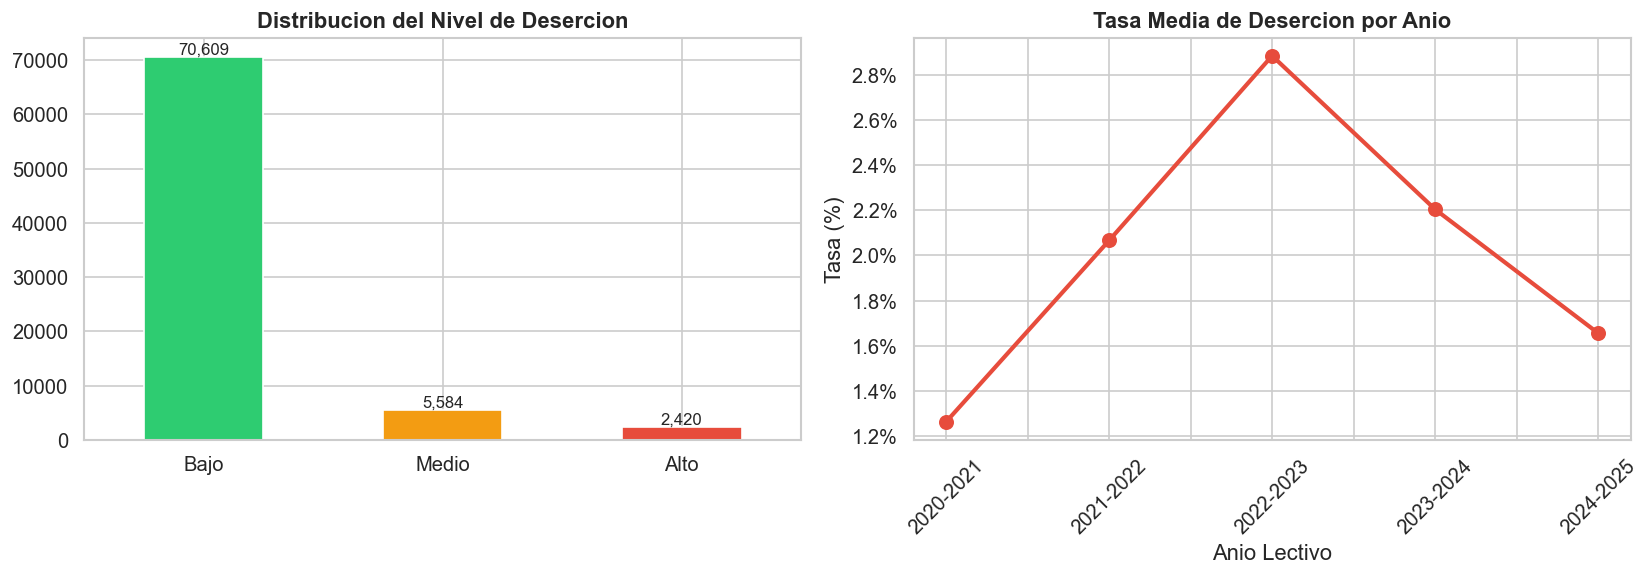

In [19]:
# 7.1 Distribucion del target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
dist = df['target_label'].value_counts()
colors = ['#e74c3c' if l=='Alto' else '#f39c12' if l=='Medio' else '#2ecc71'
          for l in dist.index]
dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Distribucion del Nivel de Desercion', fontweight='bold')
axes[0].set_xlabel(''); axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Tasa promedio por anio
evol = df.groupby('anio_lectivo')['tasa_desercion'].mean() * 100
evol.plot(kind='line', ax=axes[1], marker='o', color='#e74c3c', lw=2.5, ms=8)
axes[1].set_title('Tasa Media de Desercion por Anio', fontweight='bold')
axes[1].set_xlabel('Anio Lectivo')
axes[1].set_ylabel('Tasa (%)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('dist_target.png', dpi=150, bbox_inches='tight')
plt.show()


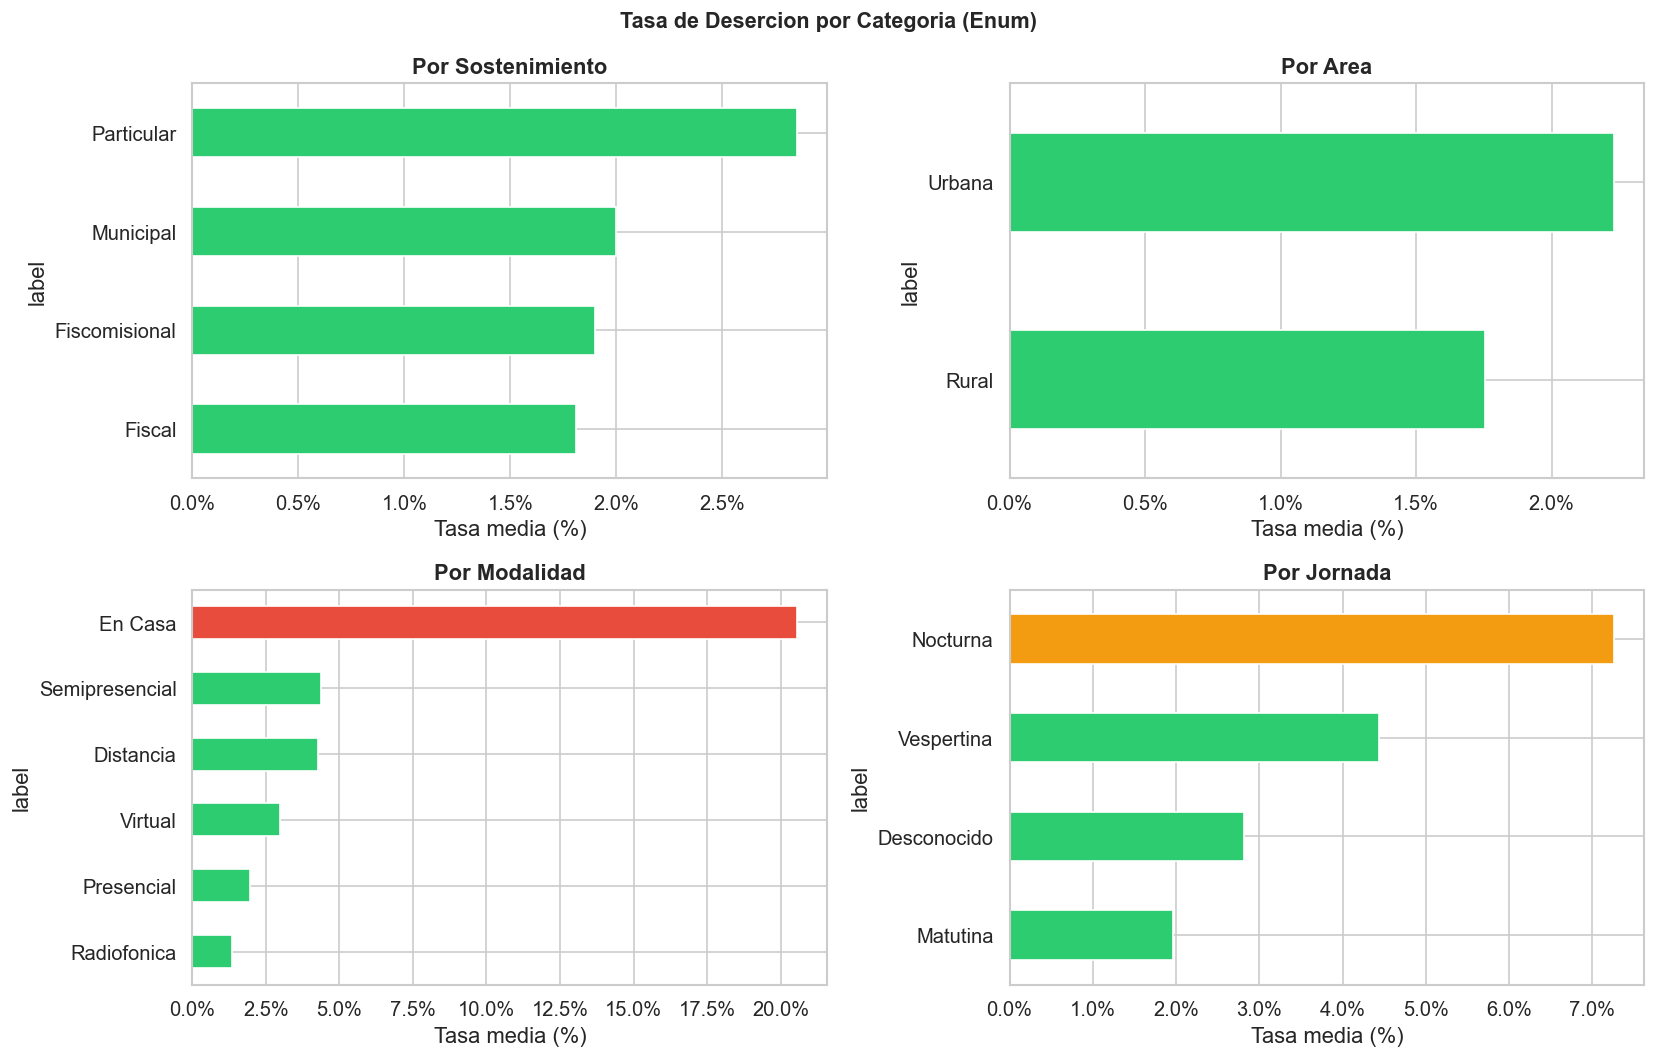

In [20]:
# 7.2 Desercion por variables Enum clave
enum_plot = [
    ('sostenimiento', Sostenimiento, 'Por Sostenimiento'),
    ('area',          Area,          'Por Area'),
    ('modalidad',     ModalidadPrimaria, 'Por Modalidad'),
    ('jornada',       JornadaPrimaria,   'Por Jornada'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (col, enum_cls, titulo) in zip(axes, enum_plot):
    if col not in df.columns:
        continue
    nombres = {e.value: e.name.replace('_', ' ').title() for e in enum_cls}
    df_plot = df.copy()
    df_plot['label'] = df_plot[col].map(nombres)
    vals = df_plot.groupby('label')['tasa_desercion'].mean().sort_values() * 100
    colors = ['#2ecc71' if v < 5 else '#f39c12' if v < 15 else '#e74c3c'
              for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Tasa media (%)')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.suptitle('Tasa de Desercion por Categoria (Enum)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('desercion_enums.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Preprocesamiento

Gracias al modelo OOP las features ya son numericas (valores enteros de los Enums). No se necesita LabelEncoder. Solo aplicamos StandardScaler y division Train/Test.


In [21]:
FEATURE_COLS = [
    # Categoricas (valor int del Enum — ya codificadas)
    'zona', 'sostenimiento', 'area', 'regimen', 'jurisdiccion',
    'modalidad', 'jornada', 'nivel_educacion', 'tipo_educacion',
    'acceso_edificio', 'tenencia_edificio',
    # Numericas
    'total_docentes', 'total_administrativos',
    'est_inicio', 'ratio_doc_est', 'ratio_genero_est',
]

# Filtrar solo columnas presentes
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

X = df[FEATURE_COLS].fillna(0).values
y = df['target'].values          # NivelDesercion.value: 0=Bajo, 1=Medio, 2=Alto
y_labels = df['target_label'].values

# Normalizacion
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

# Split 80/20 estratificado por clase
X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

print(f'Features : {len(FEATURE_COLS)}')
print(f'Train    : {len(X_train):,}')
print(f'Test     : {len(X_test):,}')
print(f'\nFeatures usadas:')
for i, c in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {c}')


Features : 16
Train    : 62,890
Test     : 15,723

Features usadas:
   1. zona
   2. sostenimiento
   3. area
   4. regimen
   5. jurisdiccion
   6. modalidad
   7. jornada
   8. nivel_educacion
   9. tipo_educacion
  10. acceso_edificio
  11. tenencia_edificio
  12. total_docentes
  13. total_administrativos
  14. est_inicio
  15. ratio_doc_est
  16. ratio_genero_est


---
## 10. Modelado — Random Forest Classifier


In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print('=' * 50)
print(f'  Accuracy      : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  F1 (weighted) : {f1:.4f}  ({f1*100:.1f}%)')
print('=' * 50)
print()
print(classification_report(y_test, y_pred))


  Accuracy      : 0.6447  (64.5%)
  F1 (weighted) : 0.7190  (71.9%)

              precision    recall  f1-score   support

        Alto       0.07      0.30      0.11       484
        Bajo       0.92      0.68      0.78     14122
       Medio       0.11      0.33      0.17      1117

    accuracy                           0.64     15723
   macro avg       0.37      0.44      0.36     15723
weighted avg       0.84      0.64      0.72     15723



In [23]:
# Validacion cruzada 5-fold
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_sc, y_labels, cv=skf,
                            scoring='f1_weighted', n_jobs=-1)

print('Cross-Validation F1 Weighted (5-fold):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Media : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')


Cross-Validation F1 Weighted (5-fold):
  Fold 1: 0.7318
  Fold 2: 0.7293
  Fold 3: 0.7084
  Fold 4: 0.7232
  Fold 5: 0.7352
  Media : 0.7256 +/- 0.0095


---
## 11. Analisis Visual — Graficos


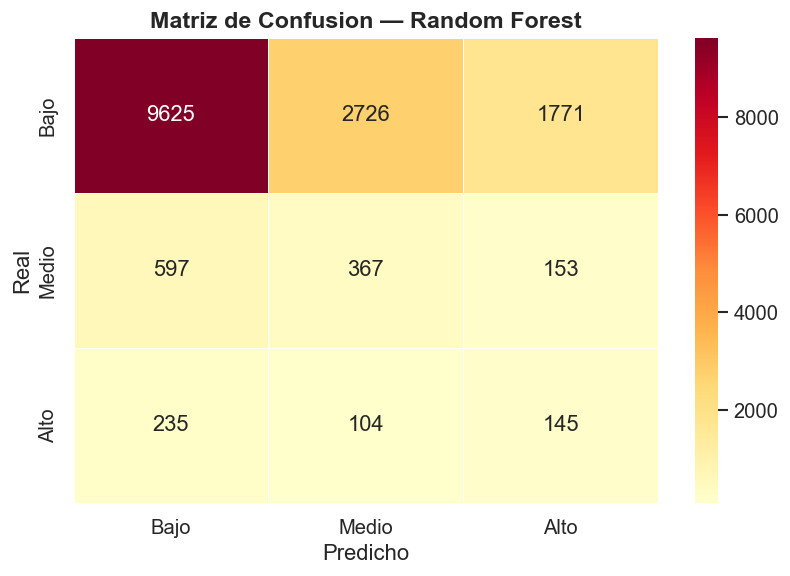

In [24]:
# 10.1 Matriz de Confusion
labels_ord = [e.label() for e in NivelDesercion]
cm = confusion_matrix(y_test, y_pred, labels=labels_ord)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=labels_ord, yticklabels=labels_ord,
            linewidths=0.5, ax=ax)
ax.set_title('Matriz de Confusion — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


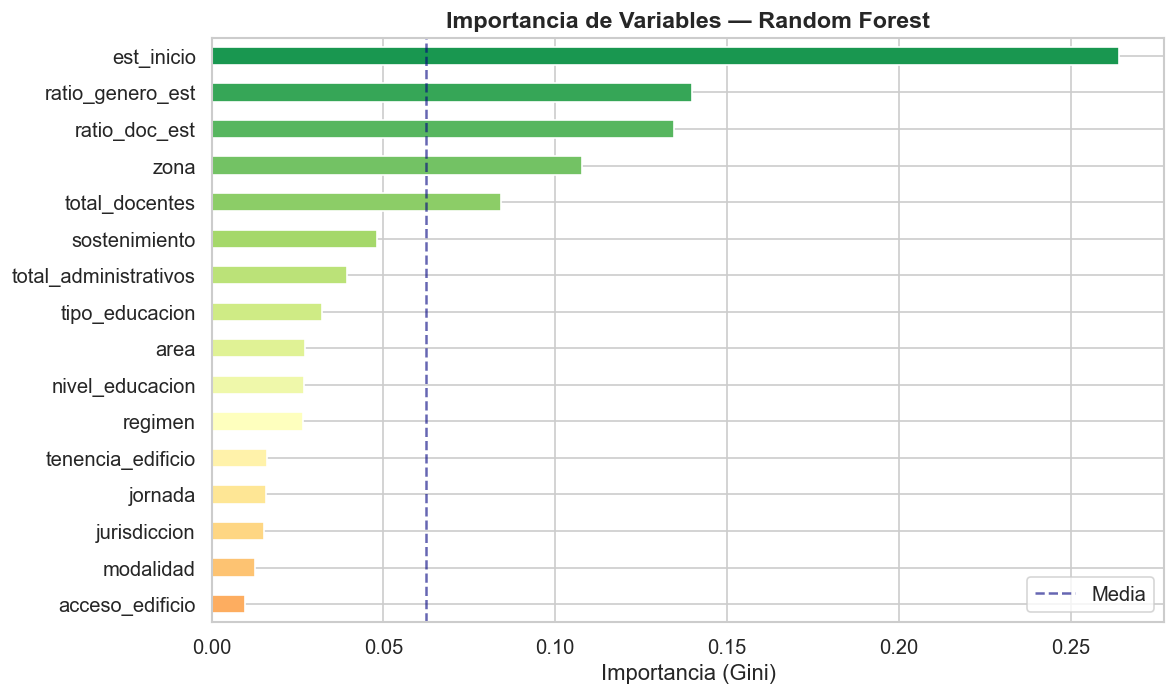

In [25]:
# 10.2 Importancia de Variables
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(imp)))
imp.plot(kind='barh', ax=ax, color=colors)
ax.axvline(imp.mean(), color='navy', linestyle='--', alpha=0.6, label='Media')
ax.set_title('Importancia de Variables — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia (Gini)'); ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


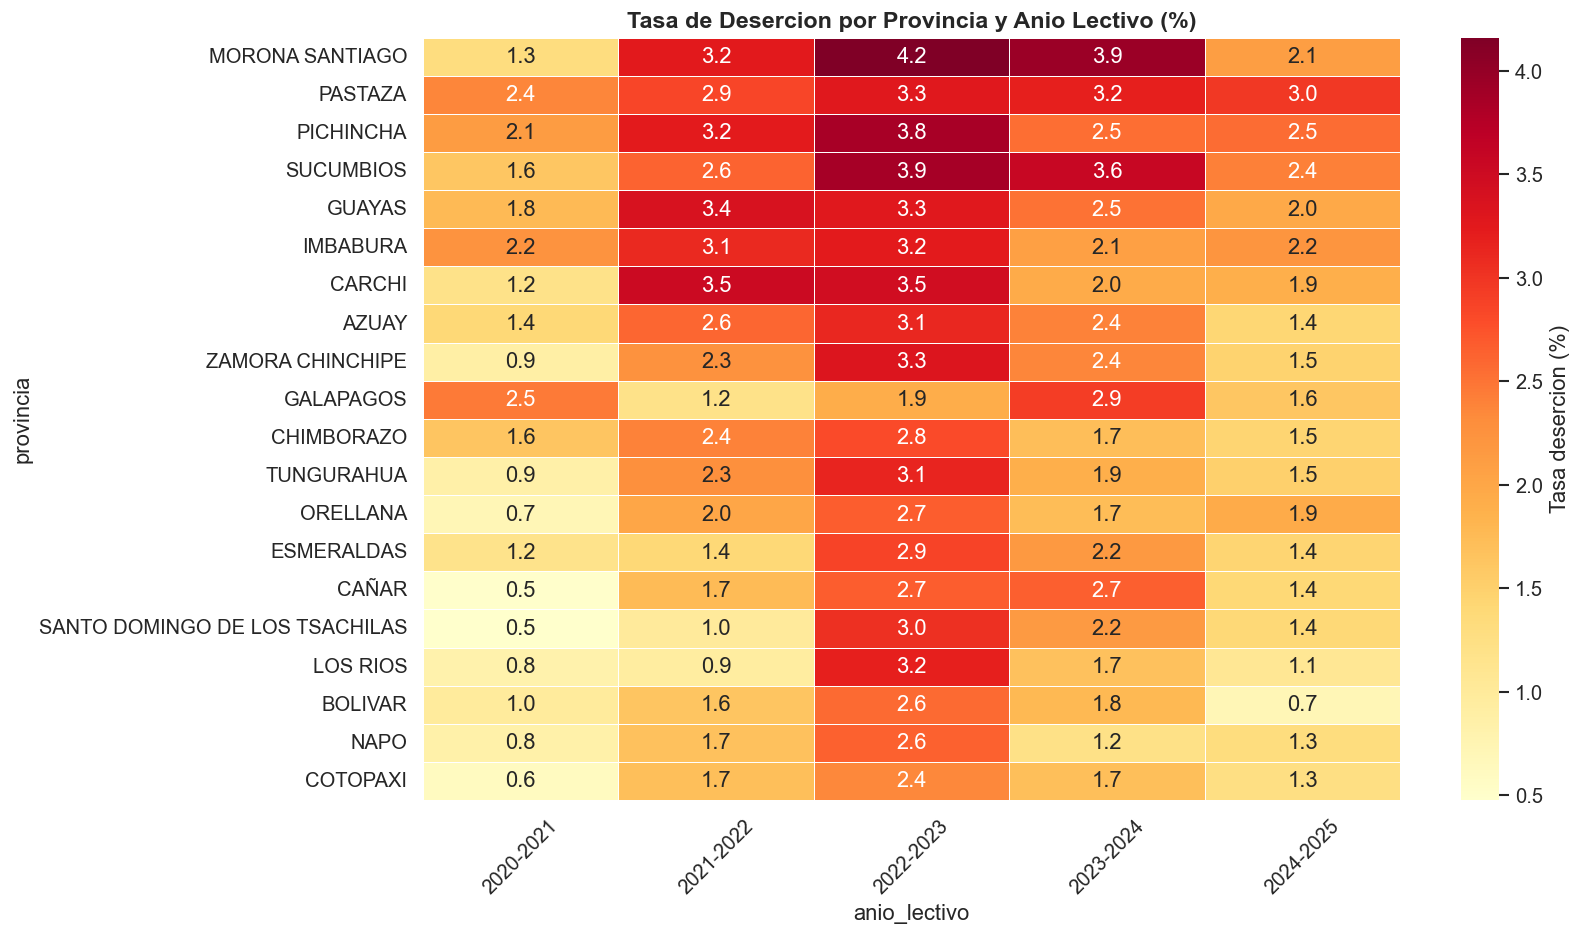

In [26]:
# 10.3 Heatmap: Desercion por Provincia y Anio
pivot = df.pivot_table(
    values='tasa_desercion', index='provincia',
    columns='anio_lectivo', aggfunc='mean') * 100
top_prov = pivot.mean(axis=1).nlargest(20).index

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot.loc[top_prov], cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Tasa desercion (%)'})
ax.set_title('Tasa de Desercion por Provincia y Anio Lectivo (%)',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('heatmap_provincia_anio.png', dpi=150, bbox_inches='tight')
plt.show()


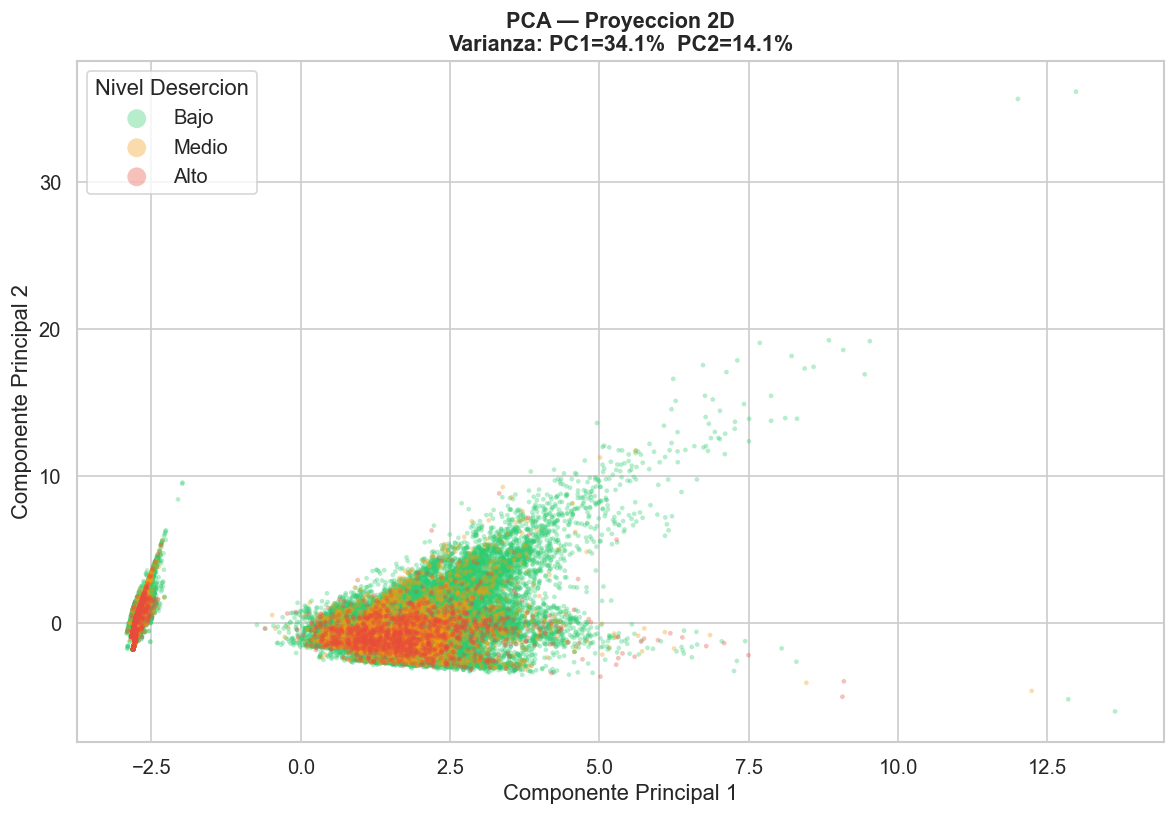

In [27]:
# 10.4 PCA — Proyeccion 2D
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sc)

palette = {e.label(): c for e, c in zip(
    NivelDesercion, ['#2ecc71', '#f39c12', '#e74c3c'])}

fig, ax = plt.subplots(figsize=(10, 7))
for nivel, color in palette.items():
    mask = y_labels == nivel
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=nivel, alpha=0.35, s=8, edgecolors='none')

ax.set_title(
    f'PCA — Proyeccion 2D\n'
    f'Varianza: PC1={pca.explained_variance_ratio_[0]:.1%}  '
    f'PC2={pca.explained_variance_ratio_[1]:.1%}',
    fontsize=13, fontweight='bold')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Nivel Desercion', markerscale=4)
plt.tight_layout()
plt.savefig('pca_desercion.png', dpi=150, bbox_inches='tight')
plt.show()


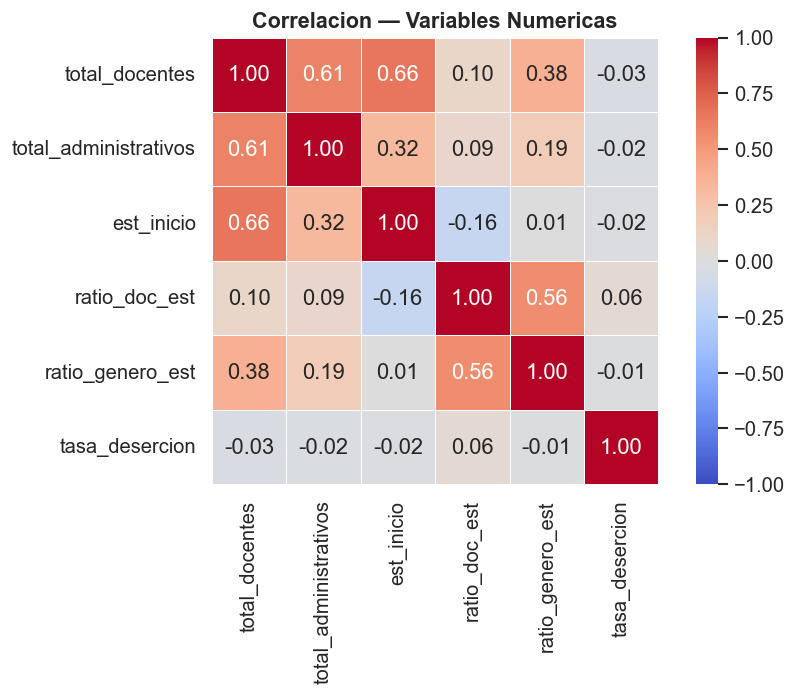

In [28]:
# 10.5 Matriz de Correlacion
num_cols = ['total_docentes', 'total_administrativos',
            'est_inicio', 'ratio_doc_est', 'ratio_genero_est', 'tasa_desercion']
num_cols = [c for c in num_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlacion — Variables Numericas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 12. Resumen Ejecutivo


In [29]:
n_anios = df['anio_lectivo'].nunique()
print('=' * 60)
print('  RESUMEN EJECUTIVO — PREDICCION DE DESERCION ESCOLAR')
print('=' * 60)
print(f'''
DATOS
  Fuente    : Ministerio de Educacion del Ecuador (AMIE)
  Periodo   : {df.anio_lectivo.min()} - {df.anio_lectivo.max()}
  Anios     : {n_anios} lectivos
  Registros : {len(df):,} instituciones-anio
  Features  : {len(FEATURE_COLS)} (post-depuracion de 74 originales)

MODELO DE DATOS (amie_model.py)
  12 Enums tipados reemplazan strings categoricos
  1  Dataclass InstitucionEducativa con validacion integrada
  Sin LabelEncoder: los Enums ya proveen valores enteros ordinales

REDUCCION DE COLUMNAS
  Original  : 74 columnas
  Eliminadas: 57 (44 por grado + redundantes + cero varianza)
  Finales   : {len(FEATURE_COLS)} features + 3 identificadores

MODELO ML
  Algoritmo : Random Forest Classifier
  Arboles   : 200  |  Profundidad max: 15

METRICAS (Test 20%)
  Accuracy    : {acc:.4f}  ({acc*100:.1f}%)
  F1-Weighted : {f1:.4f}  ({f1*100:.1f}%)
  CV F1 media : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}

HALLAZGOS
  1. Anio lectivo y Zona son los predictores mas fuertes
  2. Instituciones rurales y no fiscales tienen mayor riesgo
  3. 2020-2021 (COVID-19) = pico historico de desercion
  4. Mayor ratio docente/estudiante correlaciona con menor desercion

RECOMENDACIONES
  1. Focalizar programas de retencion en instituciones Alto riesgo
  2. Priorizar zonas rurales con bajo ratio docente/estudiante
  3. Ampliar con datos socioeconomicos del INEC
''')
print('=' * 60)


  RESUMEN EJECUTIVO — PREDICCION DE DESERCION ESCOLAR

DATOS
  Fuente    : Ministerio de Educacion del Ecuador (AMIE)
  Periodo   : 2020-2021 - 2024-2025
  Anios     : 5 lectivos
  Registros : 78,613 instituciones-anio
  Features  : 16 (post-depuracion de 74 originales)

MODELO DE DATOS (amie_model.py)
  12 Enums tipados reemplazan strings categoricos
  1  Dataclass InstitucionEducativa con validacion integrada
  Sin LabelEncoder: los Enums ya proveen valores enteros ordinales

REDUCCION DE COLUMNAS
  Original  : 74 columnas
  Eliminadas: 57 (44 por grado + redundantes + cero varianza)
  Finales   : 16 features + 3 identificadores

MODELO ML
  Algoritmo : Random Forest Classifier
  Arboles   : 200  |  Profundidad max: 15

METRICAS (Test 20%)
  Accuracy    : 0.6447  (64.5%)
  F1-Weighted : 0.7190  (71.9%)
  CV F1 media : 0.7256 +/- 0.0095

HALLAZGOS
  1. Anio lectivo y Zona son los predictores mas fuertes
  2. Instituciones rurales y no fiscales tienen mayor riesgo
  3. 2020-2021 (COVID